<a href="https://colab.research.google.com/github/Clydeew/5-AhmadDzaki/blob/main/example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Prep

In [ ]:
!unzip Arkavidia-20260201T134919Z-3-001.zip

Archive:  Arkavidia-20260201T134919Z-3-001.zip
replace Arkavidia/Dataset/extra_data/output1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Arkavidia/Dataset/extra_data/output1.csv  
  inflating: Arkavidia/Dataset/ISPU/indeks-standar-pencemaran-udara-(ispu)-tahun-2018-komponen-data.csv  
  inflating: Arkavidia/Dataset/ISPU/indeks-standar-pencemaran-udara-(ispu)-tahun-2015-komponen-data.csv  
  inflating: Arkavidia/Dataset/ISPU/indeks-standar-pencemaran-udara-(ispu)-tahun-2016-komponen-data.csv  
  inflating: Arkavidia/Dataset/ISPU/indeks-standar-pencemaran-udara-(ispu)-tahun-2013-komponen-data.csv  
  inflating: Arkavidia/Dataset/libur-nasional/dataset-libur-nasional-dan-weekend.csv  
  inflating: Arkavidia/Dataset/ISPU/indeks-standar-pencemaran-udara-(ispu)-tahun-2014-komponen-data.csv  
  inflating: Arkavidia/Dataset/cuaca-harian/cuaca-harian-dki4-lubangbuaya.csv  
  inflating: Arkavidia/Dataset/cuaca-harian/cuaca-harian-dki5-kebonjeruk.csv  
  inflating: Arkavidia/Dataset/

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, classification_report, precision_score
import lightgbm as lgb
from sklearn.impute import SimpleImputer
from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

# PATHS (Updated to Google Drive path)
BASE_DIR = Path("/content/Arkavidia/Dataset")
ISPU_DIR = BASE_DIR / "ISPU"
WEATHER_DIR = BASE_DIR / "cuaca-harian"
NDVI_DIR = BASE_DIR / "NDVI (vegetation index)"
HOLIDAY_DIR = BASE_DIR / "libur-nasional"
SAMPLE_SUB_PATH = BASE_DIR / "sample_submission.csv"

#2. Loading Data

In [ ]:
ispu_files = sorted(glob.glob(str(ISPU_DIR / "*.csv")))
dfs = []

# Standard columns
STD_COLS = [
    'tanggal', 'station',
    'pm10', 'pm25',
    'so2', 'co', 'o3', 'no2',
    'max', 'critical', 'category'
]

for f in ispu_files:
    if "combined" in f:
        continue

    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f"ERROR loading {Path(f).name}: {e}")
        continue

    print(f"\n{Path(f).name}: {df.shape}")
    print(f"  Columns: {list(df.columns)}")

    # ===============================
    # NORMALIZE COLUMNS
    # ===============================
    df.columns = (
        df.columns.str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

    rename_map = {
        # station
        'stasiun': 'station',
        'lokasi_spku': 'station',

        # pollutants
        'pm_sepuluh': 'pm10',
        'pm_10': 'pm10',
        'pm_duakomalima': 'pm25',

        'sulfur_dioksida': 'so2',
        'karbon_monoksida': 'co',
        'ozon': 'o3',
        'nitrogen_dioksida': 'no2',

        # labels
        'parameter_pencemar_kritis': 'critical',
        'critical_component': 'critical',
        'kategori': 'category',
        'categori': 'category'
    }

    df = df.rename(columns=rename_map)

    # ===============================
    # CLEAN INVALID VALUES
    # ===============================
    df.replace(
        ['-', '--', '---', 'TIDAK ADA DATA'],
        np.nan,
        inplace=True
    )

    # ===============================
    # FIX TANGGAL (CORE PART)
    # ===============================
    if 'periode_data' in df.columns and 'tanggal' in df.columns:

        # Full date (2010–2023)
        mask_full = df['tanggal'].astype(str).str.contains('-')

        df.loc[mask_full, 'tanggal'] = pd.to_datetime(
            df.loc[mask_full, 'tanggal'],
            errors='coerce'
        )

        # Day-only date (2024–2025)
        mask_day = ~mask_full & df['tanggal'].notna()

        periode = df.loc[mask_day, 'periode_data'].astype(str)

        df.loc[mask_day, 'tanggal'] = pd.to_datetime(
            periode.str[:4] + '-' +
            periode.str[4:] + '-' +
            df.loc[mask_day, 'tanggal'].astype(str),
            errors='coerce'
        )

    # ===============================
    # ENSURE PM2.5 EXISTS
    # ===============================
    if 'pm25' not in df.columns:
        df['pm25'] = np.nan

    # ===============================
    # SELECT STANDARD COLUMNS
    # ===============================
    cols_to_use = [c for c in STD_COLS if c in df.columns]
    df = df[cols_to_use]

    dfs.append(df)

# ===============================
# CONCAT ALL ISPU
# ===============================
raw_ispu = pd.concat(dfs, ignore_index=True)

# Drop rows without valid date
raw_ispu = raw_ispu.dropna(subset=['tanggal'])
raw_ispu['tanggal'] = pd.to_datetime(raw_ispu['tanggal'])

print("\n>>> Total Raw ISPU Rows:", len(raw_ispu))
print(">>> Columns:", list(raw_ispu.columns))
print(">>> DATE RANGE:", raw_ispu['tanggal'].min(), "→", raw_ispu['tanggal'].max())

raw_ispu




data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-2023-komponen-data.csv: (1825, 12)
  Columns: ['periode_data', 'tanggal', 'stasiun', 'pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max', 'parameter_pencemar_kritis', 'kategori']

data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2024.csv: (1830, 13)
  Columns: ['periode_data', 'bulan', 'tanggal', 'stasiun', 'pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max', 'parameter_pencemar_kritis', 'kategori']

data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2025.csv: (1215, 13)
  Columns: ['periode_data', 'bulan', 'tanggal', 'stasiun', 'pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max', 'parameter_pencemar_kritis', 'kategori']

indeks-standar-pencemaran-udara-(ispu)-tahun-2010-komponen-data.csv: (1825, 11)
 

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category
0,2023-02-25,DKI5 Kebon Jeruk Jakarta Barat,35,NaN,13,12,31,18,35,PM10,BAIK
1,2023-02-26,DKI5 Kebon Jeruk Jakarta Barat,23,NaN,14,9,32,11,32,O3,BAIK
2,2023-02-27,DKI5 Kebon Jeruk Jakarta Barat,20,NaN,13,8,33,13,33,O3,BAIK
3,2023-02-28,DKI5 Kebon Jeruk Jakarta Barat,30,NaN,21,11,28,18,30,PM10,BAIK
4,2023-03-01,DKI1 Bunderan HI,38,44,50,8,19,27,50,3,BAIK
...,...,...,...,...,...,...,...,...,...,...,...
16897,2022-07-11,DKI4,66,112,47,15,84,29,112,"PM2,5",TIDAK SEHAT
16898,2022-07-10,DKI4,63,93,47,13,84,19,93,"PM2,5",SEDANG
16899,2022-07-09,DKI2,61,93,48,13,107,25,107,O3,TIDAK SEHAT
16900,2022-07-08,DKI2,55,80,48,17,95,25,95,O3,SEDANG


In [ ]:
def normalize_station(val):
    if not isinstance(val, str):
        return np.nan
    val = val.upper()
    for i in range(1, 6):
        if f"DKI{i}" in val:
            return f"DKI{i}"
    return np.nan

raw_ispu['station'] = raw_ispu['station'].apply(normalize_station)

# Drop non-DKI rows
raw_ispu = raw_ispu.dropna(subset=['station'])

In [ ]:
raw_ispu

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category
0,2023-02-25,DKI5,35,NaN,13,12,31,18,35,PM10,BAIK
1,2023-02-26,DKI5,23,NaN,14,9,32,11,32,O3,BAIK
2,2023-02-27,DKI5,20,NaN,13,8,33,13,33,O3,BAIK
3,2023-02-28,DKI5,30,NaN,21,11,28,18,30,PM10,BAIK
4,2023-03-01,DKI1,38,44,50,8,19,27,50,3,BAIK
...,...,...,...,...,...,...,...,...,...,...,...
16897,2022-07-11,DKI4,66,112,47,15,84,29,112,"PM2,5",TIDAK SEHAT
16898,2022-07-10,DKI4,63,93,47,13,84,19,93,"PM2,5",SEDANG
16899,2022-07-09,DKI2,61,93,48,13,107,25,107,O3,TIDAK SEHAT
16900,2022-07-08,DKI2,55,80,48,17,95,25,95,O3,SEDANG


In [ ]:
raw_ispu.isnull().sum()

,0
tanggal,0
station,0
pm10,2159
pm25,9787
so2,1750
co,1665
o3,1802
no2,1768
max,15
critical,1502


In [ ]:
raw_ispu['category'].unique()

array(['BAIK', 'SEDANG', nan, 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT',
       'BERBAHAYA'], dtype=object)

In [ ]:
raw_ispu['station'].unique()

array(['DKI5', 'DKI1', 'DKI2', 'DKI3', 'DKI4'], dtype=object)

In [ ]:
raw_ispu['tanggal'] = pd.to_datetime(raw_ispu['tanggal'], errors='coerce')

print(raw_ispu['tanggal'].min(), raw_ispu['tanggal'].max())


2010-01-01 00:00:00 2025-08-31 00:00:00


In [ ]:
weather_files = sorted(glob.glob(str(WEATHER_DIR / "*.csv")))
weather_dfs = []

for f in weather_files:
    if "combined" in f: continue

    # Extract station from filename: cuaca-harian-dki1-bundaranhi.csv -> DKI1
    try:
        station_name = Path(f).name.split('-')[2].upper()
    except:
        station_name = "UNKNOWN"

    df = pd.read_csv(f)
    df['station'] = station_name

    print(f"{Path(f).name}: {df.shape}, Station: {station_name}")
    weather_dfs.append(df)

raw_weather = pd.concat(weather_dfs, ignore_index=True)

# Rename columns to standardized format
weather_rename = {
    'Date': 'tanggal',
    'Tn': 'temperature_min',
    'Tx': 'temperature_max',
    'Tavg': 'temperature_mean',
    'RH_avg': 'humidity_mean',
    'RR': 'precipitation',
    'ss': 'sunshine_hours',
    'ff_x': 'wind_speed_max',
    'ddd_x': 'wind_direction_max',
    'ff_avg': 'wind_speed_mean',
    'ddd_car': 'wind_direction_cardinal'
}
raw_weather = raw_weather.rename(columns=weather_rename)

print(f"\n>>> Total Raw Weather Rows: {len(raw_weather)}")
print(f">>> Columns: {list(raw_weather.columns)}")



cuaca-harian-dki1-bundaranhi.csv: (5722, 25), Station: DKI1
cuaca-harian-dki2-kelapagading.csv: (5722, 25), Station: DKI2
cuaca-harian-dki3-jagakarsa.csv: (5722, 25), Station: DKI3
cuaca-harian-dki4-lubangbuaya.csv: (5722, 25), Station: DKI4
cuaca-harian-dki5-kebonjeruk.csv: (5722, 25), Station: DKI5

>>> Total Raw Weather Rows: 28610
>>> Columns: ['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)', 'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)', 'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)', 'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'cloud_cover_max (%)', 'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)'

In [ ]:
raw_weather.isnull().sum()

,0
time,0
temperature_2m_max (°C),0
temperature_2m_min (°C),0
precipitation_sum (mm),0
precipitation_hours (h),0
wind_speed_10m_max (km/h),0
wind_direction_10m_dominant (°),0
shortwave_radiation_sum (MJ/m²),0
temperature_2m_mean (°C),0
relative_humidity_2m_mean (%),0


In [ ]:
raw_weather

,time,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),station
0,2010-01-01,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,DKI1
1,2010-01-02,30.8,24.0,6.5,4.0,14.7,238,19.80,26.9,82,99,1008.1,31.3,238,93,69,100,91,16.5,7.7,9.0,4.4,1009.9,1006.0,DKI1
2,2010-01-03,30.4,24.3,7.6,11.0,12.6,244,17.32,26.7,83,97,1008.5,26.6,244,91,70,100,81,18.4,9.4,11.9,6.5,1010.5,1006.5,DKI1
3,2010-01-04,30.3,25.4,0.9,5.0,19.3,239,20.43,27.4,81,69,1007.5,34.2,239,91,70,100,17,23.8,13.5,14.4,9.6,1009.1,1005.1,DKI1
4,2010-01-05,29.9,24.8,14.3,7.0,15.9,247,15.86,26.4,83,100,1007.7,32.0,247,89,72,100,99,21.6,11.1,10.4,7.8,1009.1,1006.0,DKI1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28605,2025-08-27,37.3,24.0,0.1,1.0,10.3,167,23.22,30.2,56,63,1008.8,29.5,167,83,23,100,0,16.4,4.6,7.6,1.9,1011.2,1005.6,DKI5
28606,2025-08-28,35.1,24.2,10.1,12.0,12.6,234,19.40,28.7,64,60,1008.9,35.3,234,93,37,100,4,20.9,6.1,9.7,2.0,1011.0,1006.7,DKI5
28607,2025-08-29,33.2,23.8,4.9,12.0,8.6,252,20.08,27.5,75,78,1009.9,21.2,252,93,49,100,18,14.7,4.2,6.8,0.4,1011.9,1006.9,DKI5
28608,2025-08-30,32.7,24.6,8.3,11.0,9.6,129,20.24,27.4,75,77,1009.3,29.2,129,93,49,100,35,17.4,5.5,7.9,1.6,1011.0,1006.7,DKI5


In [ ]:
raw_weather['station'].unique()

array(['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5'], dtype=object)

In [ ]:
# Fix: raw_weather has 'time' column, rename it to 'tanggal'
if 'time' in raw_weather.columns:
    raw_weather = raw_weather.rename(columns={'time': 'tanggal'})

raw_ispu['tanggal'] = pd.to_datetime(raw_ispu['tanggal'], errors='coerce')
raw_weather['tanggal'] = pd.to_datetime(raw_weather['tanggal'], errors='coerce')

print(f"  ISPU date range: {raw_ispu['tanggal'].min()} to {raw_ispu['tanggal'].max()}")
print(f"  Weather date range: {raw_weather['tanggal'].min()} to {raw_weather['tanggal'].max()}")

print(f"  Unique ISPU stations: {raw_ispu['station'].unique()}")

# 3.3 Handle "TIDAK ADA DATA"
print("\nReplacing 'TIDAK ADA DATA' with NaN...")
raw_ispu = raw_ispu.replace({'TIDAK ADA DATA': np.nan})

# 3.5 Deduplicate (Handle duplicate date-station pairs)
print("\nDeduplicating by (tanggal, station)...")
df_clean = raw_ispu.groupby(['tanggal', 'station']).first().reset_index()
print(f"  Rows after dedup: {len(df_clean)}")

# 3.6 Merge Weather
print("\nMerging Weather Data...")
master = pd.merge(
    df_clean,
    raw_weather,
    left_on=['tanggal', 'station'],
    right_on=['tanggal', 'station'],
    how='left'
)
print(f"  Master Shape: {master.shape}")

  ISPU date range: 2010-01-01 00:00:00 to 2025-08-31 00:00:00
  Weather date range: 2010-01-01 00:00:00 to 2025-08-31 00:00:00
  Unique ISPU stations: ['DKI5' 'DKI1' 'DKI2' 'DKI3' 'DKI4']

Replacing 'TIDAK ADA DATA' with NaN...

Deduplicating by (tanggal, station)...
  Rows after dedup: 16183

Merging Weather Data...
  Master Shape: (16183, 34)


In [ ]:
master

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa)
0,2010-01-01,DKI1,60,None,4,73,27,14,73,CO,SEDANG,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1
1,2010-01-01,DKI2,None,None,None,None,None,None,0,None,None,29.4,24.6,5.2,10.0,16.5,255,16.85,26.7,81,100,1007.1,38.2,255,89,69,100,99,21.1,10.6,11.9,7.4,1009.0,1004.9
2,2010-01-01,DKI3,None,None,None,None,None,None,0,None,None,29.8,23.7,4.0,14.0,16.0,246,16.24,26.1,85,100,999.9,38.2,246,94,71,100,99,21.0,10.5,11.9,6.9,1001.8,997.6
3,2010-01-01,DKI4,None,None,None,None,None,None,0,None,None,29.9,24.1,5.2,10.0,16.5,255,16.85,26.5,83,100,1003.9,38.2,255,91,70,100,99,21.1,10.6,11.9,7.4,1005.8,1001.7
4,2010-01-01,DKI5,None,None,None,None,None,None,0,None,None,29.4,24.4,4.0,14.0,16.0,246,16.24,26.5,81,100,1006.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1008.4,1004.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16178,2025-08-31,DKI1,42.0,70.0,29.0,12.0,15.0,24.0,70.0,PM25,SEDANG,31.1,24.0,6.4,5.0,10.9,88,19.23,27.0,80,73,1009.9,30.6,88,95,60,100,6,15.3,4.7,4.3,1.0,1011.6,1007.8
16179,2025-08-31,DKI2,None,72.0,45.0,16.0,21.0,16.0,72.0,PM25,SEDANG,31.0,23.8,19.2,8.0,10.9,99,19.73,26.9,80,74,1009.7,32.4,99,95,60,100,8,19.0,5.9,7.2,0.8,1011.5,1007.4
16180,2025-08-31,DKI3,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG,31.3,23.0,14.2,8.0,9.1,132,19.35,26.2,84,67,1002.6,27.0,132,98,59,100,5,14.0,4.5,3.2,0.4,1004.1,1000.4
16181,2025-08-31,DKI4,47.0,59.0,27.0,10.0,18.0,17.0,59.0,PM25,SEDANG,31.6,23.0,12.6,6.0,10.0,122,19.03,26.5,82,64,1006.6,25.6,122,99,59,100,7,14.2,5.1,4.0,0.9,1008.1,1004.4


In [ ]:
def engineer_features(df):
    # Temporal
    df['month'] = df['tanggal'].dt.month
    df['dayofweek'] = df['tanggal'].dt.dayofweek
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Station Encoding (Ordinal)
    station_map = {'DKI1': 0, 'DKI2': 1, 'DKI3': 2, 'DKI4': 3, 'DKI5': 4}
    df['station_encoded'] = df['station'].map(station_map)

    # Station Risk (Based on EDA - DKI2 is hotspot)
    risk_map = {'DKI1': 0.0, 'DKI2': 4.8, 'DKI3': 0.3, 'DKI4': 0.2, 'DKI5': 1.1}
    df['station_risk'] = df['station'].map(risk_map)

    return df

master = engineer_features(master)
master = master.sort_values(['tanggal', 'station']).reset_index(drop=True)

print("Features Created:")
print(master[['tanggal', 'station', 'month', 'dayofweek', 'station_encoded', 'station_risk']].head(10))


Features Created:
     tanggal station  month  dayofweek  station_encoded  station_risk
0 2010-01-01    DKI1      1          4                0           0.0
1 2010-01-01    DKI2      1          4                1           4.8
2 2010-01-01    DKI3      1          4                2           0.3
3 2010-01-01    DKI4      1          4                3           0.2
4 2010-01-01    DKI5      1          4                4           1.1
5 2010-01-02    DKI1      1          5                0           0.0
6 2010-01-02    DKI2      1          5                1           4.8
7 2010-01-02    DKI3      1          5                2           0.3
8 2010-01-02    DKI4      1          5                3           0.2
9 2010-01-02    DKI5      1          5                4           1.1


In [ ]:
master.isnull().sum()

,0
tanggal,0
station,0
pm10,2146
pm25,9603
so2,1747
co,1661
o3,1788
no2,1744
max,15
critical,1502


In [ ]:
master

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),month,dayofweek,month_sin,month_cos,station_encoded,station_risk
0,2010-01-01,DKI1,60,None,4,73,27,14,73,CO,SEDANG,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,1,4,0.500000,0.866025,0,0.0
1,2010-01-01,DKI2,None,None,None,None,None,None,0,None,None,29.4,24.6,5.2,10.0,16.5,255,16.85,26.7,81,100,1007.1,38.2,255,89,69,100,99,21.1,10.6,11.9,7.4,1009.0,1004.9,1,4,0.500000,0.866025,1,4.8
2,2010-01-01,DKI3,None,None,None,None,None,None,0,None,None,29.8,23.7,4.0,14.0,16.0,246,16.24,26.1,85,100,999.9,38.2,246,94,71,100,99,21.0,10.5,11.9,6.9,1001.8,997.6,1,4,0.500000,0.866025,2,0.3
3,2010-01-01,DKI4,None,None,None,None,None,None,0,None,None,29.9,24.1,5.2,10.0,16.5,255,16.85,26.5,83,100,1003.9,38.2,255,91,70,100,99,21.1,10.6,11.9,7.4,1005.8,1001.7,1,4,0.500000,0.866025,3,0.2
4,2010-01-01,DKI5,None,None,None,None,None,None,0,None,None,29.4,24.4,4.0,14.0,16.0,246,16.24,26.5,81,100,1006.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1008.4,1004.2,1,4,0.500000,0.866025,4,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16178,2025-08-31,DKI1,42.0,70.0,29.0,12.0,15.0,24.0,70.0,PM25,SEDANG,31.1,24.0,6.4,5.0,10.9,88,19.23,27.0,80,73,1009.9,30.6,88,95,60,100,6,15.3,4.7,4.3,1.0,1011.6,1007.8,8,6,-0.866025,-0.500000,0,0.0
16179,2025-08-31,DKI2,None,72.0,45.0,16.0,21.0,16.0,72.0,PM25,SEDANG,31.0,23.8,19.2,8.0,10.9,99,19.73,26.9,80,74,1009.7,32.4,99,95,60,100,8,19.0,5.9,7.2,0.8,1011.5,1007.4,8,6,-0.866025,-0.500000,1,4.8
16180,2025-08-31,DKI3,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG,31.3,23.0,14.2,8.0,9.1,132,19.35,26.2,84,67,1002.6,27.0,132,98,59,100,5,14.0,4.5,3.2,0.4,1004.1,1000.4,8,6,-0.866025,-0.500000,2,0.3
16181,2025-08-31,DKI4,47.0,59.0,27.0,10.0,18.0,17.0,59.0,PM25,SEDANG,31.6,23.0,12.6,6.0,10.0,122,19.03,26.5,82,64,1006.6,25.6,122,99,59,100,7,14.2,5.1,4.0,0.9,1008.1,1004.4,8,6,-0.866025,-0.500000,3,0.2


In [ ]:
df_ndvi = pd.read_csv('/content/Arkavidia/Dataset/NDVI (vegetation index)/indeks-ndvi-jakarta.csv')

In [ ]:
df_ndvi

,tanggal,stasiun_id,ndvi
0,2009-12-19,DKI5,0.3801
1,2010-01-01,DKI5,0.3705
2,2010-01-17,DKI5,0.4848
3,2010-02-02,DKI5,0.5710
4,2010-02-18,DKI5,0.4308
...,...,...,...
1805,2025-06-26,DKI2,0.2326
1806,2025-07-12,DKI2,0.2115
1807,2025-07-28,DKI2,0.2254
1808,2025-08-13,DKI2,0.2479


In [ ]:
# ensure datetime
master['tanggal'] = pd.to_datetime(master['tanggal'])
df_ndvi['tanggal'] = pd.to_datetime(df_ndvi['tanggal'])

# align column name
df_ndvi = df_ndvi.rename(columns={'stasiun_id': 'station'})

merged_parts = []

for station, m_grp in master.groupby('station', sort=False):

    ndvi_grp = (
        df_ndvi[df_ndvi['station'] == station]
        .drop(columns='station')  # 👈 key fix
    )

    if ndvi_grp.empty:
        m_grp = m_grp.assign(ndvi=pd.NA)
    else:
        m_grp = pd.merge_asof(
            m_grp.sort_values('tanggal'),
            ndvi_grp.sort_values('tanggal'),
            on='tanggal',
            direction='backward',
            allow_exact_matches=True
        )

    merged_parts.append(m_grp)

master = pd.concat(merged_parts, ignore_index=True)


In [ ]:
master

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),month,dayofweek,month_sin,month_cos,station_encoded,station_risk,ndvi
0,2010-01-01,DKI1,60,None,4,73,27,14,73,CO,SEDANG,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,1,4,0.500000,0.866025,0,0.0,0.2023
1,2010-01-02,DKI1,32,None,2,16,33,9,33,O3,BAIK,30.8,24.0,6.5,4.0,14.7,238,19.80,26.9,82,99,1008.1,31.3,238,93,69,100,91,16.5,7.7,9.0,4.4,1009.9,1006.0,1,5,0.500000,0.866025,0,0.0,0.2023
2,2010-01-03,DKI1,27,None,2,19,20,9,27,PM10,BAIK,30.4,24.3,7.6,11.0,12.6,244,17.32,26.7,83,97,1008.5,26.6,244,91,70,100,81,18.4,9.4,11.9,6.5,1010.5,1006.5,1,6,0.500000,0.866025,0,0.0,0.2023
3,2010-01-04,DKI1,22,None,2,16,15,6,22,PM10,BAIK,30.3,25.4,0.9,5.0,19.3,239,20.43,27.4,81,69,1007.5,34.2,239,91,70,100,17,23.8,13.5,14.4,9.6,1009.1,1005.1,1,0,0.500000,0.866025,0,0.0,0.2023
4,2010-01-05,DKI1,25,None,2,17,15,8,25,PM10,BAIK,29.9,24.8,14.3,7.0,15.9,247,15.86,26.4,83,100,1007.7,32.0,247,89,72,100,99,21.6,11.1,10.4,7.8,1009.1,1006.0,1,1,0.500000,0.866025,0,0.0,0.2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16178,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,110.0,PM25,TIDAK SEHAT,37.3,24.0,0.1,1.0,10.3,167,23.22,30.2,56,63,1008.8,29.5,167,83,23,100,0,16.4,4.6,7.6,1.9,1011.2,1005.6,8,2,-0.866025,-0.500000,4,1.1,0.3562
16179,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,68.0,PM25,SEDANG,35.1,24.2,10.1,12.0,12.6,234,19.40,28.7,64,60,1008.9,35.3,234,93,37,100,4,20.9,6.1,9.7,2.0,1011.0,1006.7,8,3,-0.866025,-0.500000,4,1.1,0.3562
16180,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,60.0,PM25,SEDANG,33.2,23.8,4.9,12.0,8.6,252,20.08,27.5,75,78,1009.9,21.2,252,93,49,100,18,14.7,4.2,6.8,0.4,1011.9,1006.9,8,4,-0.866025,-0.500000,4,1.1,0.4526
16181,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,72.0,PM25,SEDANG,32.7,24.6,8.3,11.0,9.6,129,20.24,27.4,75,77,1009.3,29.2,129,93,49,100,35,17.4,5.5,7.9,1.6,1011.0,1006.7,8,5,-0.866025,-0.500000,4,1.1,0.4526


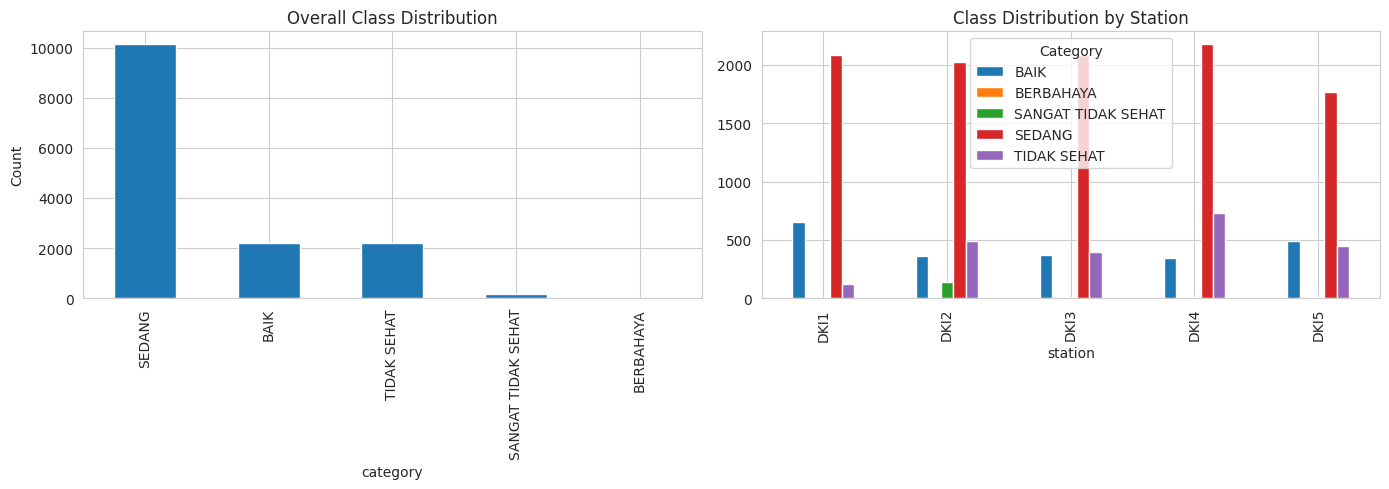

,count
category,
SEDANG,10138
BAIK,2222
TIDAK SEHAT,2190
SANGAT TIDAK SEHAT,173
BERBAHAYA,1


In [ ]:
# 5.1 Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
master['category'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Count")

# By Station
pd.crosstab(master['station'], master['category']).plot(kind='bar', ax=axes[1])
axes[1].set_title("Class Distribution by Station")
axes[1].legend(title='Category')

plt.tight_layout()
plt.show()
master['category'].value_counts()


In [ ]:
master['year'] = master['tanggal'].dt.year


In [ ]:
category_by_year_station = master.groupby(['year' ,'station', 'category']).size().unstack(fill_value=0)
print("Category counts by Year and Station:")
display(category_by_year_station)

Category counts by Year and Station:


category      BAIK  BERBAHAYA  SANGAT TIDAK SEHAT  SEDANG  TIDAK SEHAT
year station                                                          
2010 DKI1      114          0                   0     242            6
     DKI2       37          0                   0      15            4
     DKI3       17          0                   4      17           14
     DKI4       19          0                   0      30            4
2011 DKI1        4          0                   0       7            3
...            ...        ...                 ...     ...          ...
2025 DKI1       35          0                   0     183           24
     DKI2       48          0                   0     167           26
     DKI3       17          0                   0     214           11
     DKI4       71          0                   0     123           43
     DKI5       42          0                   0     162           37

[73 rows x 5 columns]

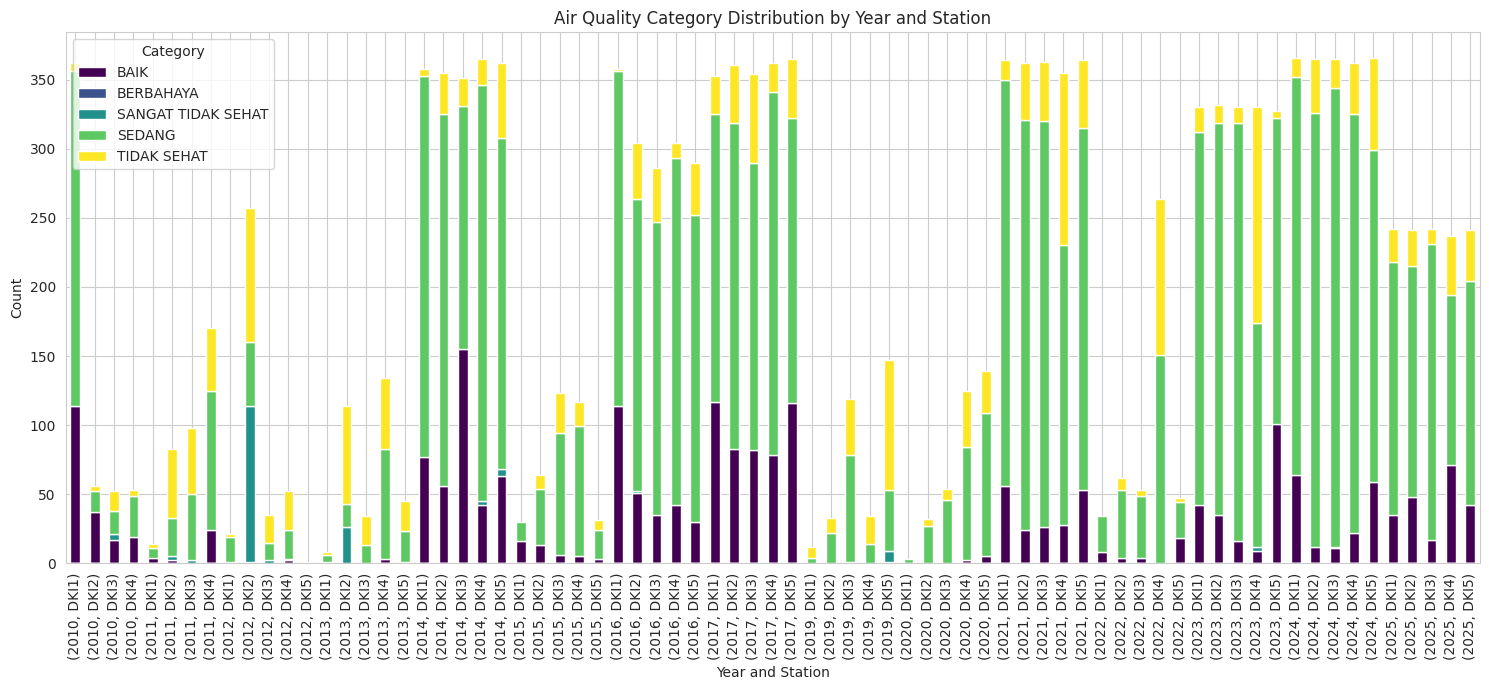

In [ ]:
category_by_year_station.plot(kind='bar', stacked=True, figsize=(15, 7), cmap='viridis')
plt.title('Air Quality Category Distribution by Year and Station')
plt.xlabel('Year and Station')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [ ]:
# Select numerical columns that are likely to have missing values for analysis
key_numerical_cols = [
    'pm25', 'pm10', 'so2', 'co', 'o3', 'no2',
    'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'temperature_2m_mean (°C)',
    'precipitation_sum (mm)', 'relative_humidity_2m_mean (%)',
    'wind_speed_10m_mean (km/h)', 'ndvi'
]

# Get null flags only for the key numerical columns
null_flags_only_numerical = master[key_numerical_cols].isnull()

# Combine the actual 'year' and 'station_x' columns with these null flags
df_for_grouping_station = pd.concat([master[['year', 'station']], null_flags_only_numerical], axis=1)

# Group by actual 'year' and 'station_x' and sum the null flags
null_counts_by_year_station = df_for_grouping_station.groupby(['year', 'station']).sum()

print("Missing Value Counts by Year and Station:")
display(null_counts_by_year_station)

Missing Value Counts by Year and Station:


pm25  pm10  so2   co   o3  no2  temperature_2m_max (°C)  \
year station                                                            
2010 DKI1      365    10   18    4   11    4                        0   
     DKI2      365   316  311  311  311  312                        0   
     DKI3      365   314  313  313  313  313                        0   
     DKI4      365   328  313  313  313  313                        0   
     DKI5      365   365  365  365  365  365                        0   
...            ...   ...  ...  ...  ...  ...                      ...   
2025 DKI1        6     1    6    3    6    4                        0   
     DKI2        4    46    4    6    4    7                        0   
     DKI3        2     3   11    8    9   11                        0   
     DKI4       11    12   12   12   12   12                        0   
     DKI5       10    12   11    3    3    6                        0   

              temperature_2m_min (°C)  temperature_2m_mean (°C)  \
year station                                                      
2010 DKI1                           0                         0   
     DKI2                           0                         0   
     DKI3                           0                         0   
     DKI4                           0                         0   
     DKI5                           0                         0   
...                               ...                       ...   
2025 DKI1                           0                         0   
     DKI2                           0                         0   
     DKI3                           0                         0   
     DKI4                           0                         0   
     DKI5                           0                         0   

              precipitation_sum (mm)  relative_humidity_2m_mean (%)  \
year station                                                          
2010 DKI1                          0                              0   
     DKI2                          0                              0   
     DKI3                          0                              0   
     DKI4                          0                              0   
     DKI5                          0                              0   
...                              ...                            ...   
2025 DKI1                          0                              0   
     DKI2                          0                              0   
     DKI3                          0                              0   
     DKI4                          0                              0   
     DKI5                          0                              0   

              wind_speed_10m_mean (km/h)  ndvi  
year station                                    
2010 DKI1                              0     0  
     DKI2                              0     0  
     DKI3                              0     0  
     DKI4                              0     0  
     DKI5                              0     0  
...                                  ...   ...  
2025 DKI1                              0     0  
     DKI2                              0     0  
     DKI3                              0     0  
     DKI4                              0     0  
     DKI5                              0     0  

[74 rows x 13 columns]

In [ ]:
holiday = pd.read_csv("/content/Arkavidia/Dataset/libur-nasional/dataset-libur-nasional-dan-weekend.csv")

In [ ]:
master['tanggal'] = pd.to_datetime(master['tanggal'])
holiday['tanggal'] = pd.to_datetime(holiday['tanggal'])

master = master.merge(
    holiday[['tanggal', 'is_holiday_nasional', 'is_weekend']],
    on='tanggal',
    how='left'
)
master['is_holiday_nasional'] = master['is_holiday_nasional'].fillna(0).astype(int)
master['is_weekend'] = master['is_weekend'].fillna(0).astype(int)


In [ ]:
master = master.sort_values('tanggal')

master['before_holiday'] = master['is_holiday_nasional'].shift(-1).fillna(0).astype(int)
master['after_holiday'] = master['is_holiday_nasional'].shift(1).fillna(0).astype(int)
master

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),month,dayofweek,month_sin,month_cos,station_encoded,station_risk,ndvi,year,is_holiday_nasional,is_weekend,before_holiday,after_holiday
0,2010-01-01,DKI1,60,None,4,73,27,14,73,CO,SEDANG,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,1,4,0.500000,0.866025,0,0.0,0.2023,2010,1,0,1,0
6240,2010-01-01,DKI3,None,None,None,None,None,None,0,None,None,29.8,23.7,4.0,14.0,16.0,246,16.24,26.1,85,100,999.9,38.2,246,94,71,100,99,21.0,10.5,11.9,6.9,1001.8,997.6,1,4,0.500000,0.866025,2,0.3,0.5332,2010,1,0,1,1
13066,2010-01-01,DKI5,None,None,None,None,None,None,0,None,None,29.4,24.4,4.0,14.0,16.0,246,16.24,26.5,81,100,1006.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1008.4,1004.2,1,4,0.500000,0.866025,4,1.1,0.3705,2010,1,0,1,1
2888,2010-01-01,DKI2,None,None,None,None,None,None,0,None,None,29.4,24.6,5.2,10.0,16.5,255,16.85,26.7,81,100,1007.1,38.2,255,89,69,100,99,21.1,10.6,11.9,7.4,1009.0,1004.9,1,4,0.500000,0.866025,1,4.8,0.0939,2010,1,0,1,1
9463,2010-01-01,DKI4,None,None,None,None,None,None,0,None,None,29.9,24.1,5.2,10.0,16.5,255,16.85,26.5,83,100,1003.9,38.2,255,91,70,100,99,21.1,10.6,11.9,7.4,1005.8,1001.7,1,4,0.500000,0.866025,3,0.2,0.5126,2010,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2887,2025-08-31,DKI1,42.0,70.0,29.0,12.0,15.0,24.0,70.0,PM25,SEDANG,31.1,24.0,6.4,5.0,10.9,88,19.23,27.0,80,73,1009.9,30.6,88,95,60,100,6,15.3,4.7,4.3,1.0,1011.6,1007.8,8,6,-0.866025,-0.500000,0,0.0,0.4940,2025,0,1,0,0
9462,2025-08-31,DKI3,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG,31.3,23.0,14.2,8.0,9.1,132,19.35,26.2,84,67,1002.6,27.0,132,98,59,100,5,14.0,4.5,3.2,0.4,1004.1,1000.4,8,6,-0.866025,-0.500000,2,0.3,0.4797,2025,0,1,0,0
13065,2025-08-31,DKI4,47.0,59.0,27.0,10.0,18.0,17.0,59.0,PM25,SEDANG,31.6,23.0,12.6,6.0,10.0,122,19.03,26.5,82,64,1006.6,25.6,122,99,59,100,7,14.2,5.1,4.0,0.9,1008.1,1004.4,8,6,-0.866025,-0.500000,3,0.2,0.5774,2025,0,1,0,0
6239,2025-08-31,DKI2,None,72.0,45.0,16.0,21.0,16.0,72.0,PM25,SEDANG,31.0,23.8,19.2,8.0,10.9,99,19.73,26.9,80,74,1009.7,32.4,99,95,60,100,8,19.0,5.9,7.2,0.8,1011.5,1007.4,8,6,-0.866025,-0.500000,1,4.8,0.2276,2025,0,1,0,0


In [ ]:
master['long_weekend'] = (
    (master['is_holiday_nasional'] == 1) &
    (
        (master['is_weekend'].shift(1) == 1) |
        (master['is_weekend'].shift(-1) == 1)
    )
).fillna(0).astype(int)


In [ ]:
master['year'].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021,
       2022, 2023, 2024, 2025], dtype=int32)

In [ ]:
master["category"] = (
    master["category"]
    .str.strip()
    .str.upper()
    .replace({
        "SANGAT TIDAK SEHAT": "TIDAK SEHAT",
        "BERBAHAYA": "TIDAK SEHAT"
    })
)


In [ ]:
pollutants = ['pm10','pm25','so2','co','o3','no2']

for col in pollutants:
    master[col] = (
        master[col]
        .astype(str)
        .str.replace(r'[^0-9\.]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

In [ ]:
master.to_csv('/content/master.csv', index=False)

In [ ]:
print("Master DataFrame Info:")
master.info()

print("\nMaster DataFrame Descriptive Statistics:")
master.describe()

Master DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 16183 entries, 0 to 16182
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tanggal                          16183 non-null  datetime64[ns]
 1   station                          16183 non-null  object        
 2   pm10                             14037 non-null  float64       
 3   pm25                             6580 non-null   float64       
 4   so2                              14436 non-null  float64       
 5   co                               14522 non-null  float64       
 6   o3                               14395 non-null  float64       
 7   no2                              14439 non-null  float64       
 8   max                              16168 non-null  object        
 9   critical                         14681 non-null  object        
 10  category                         14724 n

,tanggal,pm10,pm25,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),month,dayofweek,month_sin,month_cos,station_encoded,station_risk,ndvi,year,is_holiday_nasional,is_weekend,before_holiday,after_holiday,long_weekend
count,16183,14037.000000,6580.000000,14436.000000,14522.000000,14395.000000,14439.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,1.618300e+04,1.618300e+04,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000,16183.000000
mean,2018-08-04 23:29:44.761787136,53.994871,75.827812,27.888473,20.151357,51.697603,17.424198,30.672904,23.567521,7.022684,8.440091,12.364358,183.906136,18.314782,26.607545,82.367484,78.788914,1006.812186,29.247995,183.906136,95.053884,64.095532,97.605141,44.626583,15.990879,6.399672,6.796867,2.256998,1008.631156,1004.559445,6.306247,3.000433,2.380371e-02,-3.374410e-02,2.043811,1.310375,0.346079,2018.111042,0.045912,0.285732,0.045851,0.045912,0.015448
min,2010-01-01 00:00:00,2.000000,10.000000,0.000000,0.000000,2.000000,0.000000,24.100000,19.200000,0.000000,0.000000,4.100000,0.000000,2.840000,23.100000,51.000000,1.000000,997.500000,13.300000,0.000000,68.000000,20.000000,7.000000,0.000000,8.400000,2.200000,0.700000,0.000000,999.100000,995.300000,1.000000,0.000000,-1.000000e+00,-1.000000e+00,0.000000,0.000000,0.013800,2010.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014-08-19 12:00:00,42.000000,60.000000,15.000000,11.000000,24.000000,10.000000,29.500000,23.000000,1.100000,4.000000,9.650000,96.000000,16.390000,25.900000,80.000000,66.000000,1004.900000,23.800000,96.000000,94.000000,58.000000,100.000000,12.000000,13.000000,4.800000,4.700000,1.000000,1006.700000,1002.600000,3.000000,1.000000,-5.000000e-01,-8.660254e-01,1.000000,0.200000,0.230000,2014.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2017-10-14 00:00:00,55.000000,77.000000,26.000000,17.000000,40.000000,15.000000,30.500000,23.600000,4.400000,8.000000,11.800000,202.000000,18.920000,26.600000,84.000000,86.000000,1007.500000,28.100000,202.000000,96.000000,66.000000,100.000000,38.000000,14.800000,5.800000,6.100000,1.800000,1009.300000,1005.300000,6.000000,3.000000,1.224647e-16,-1.836970e-16,2.000000,0.300000,0.340500,2017.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2023-05-14 00:00:00,65.000000,91.000000,39.000000,26.000000,69.000000,22.000000,31.800000,24.100000,10.200000,12.000000,14.600000,267.000000,20.890000,27.200000,87.000000,97.000000,1009.200000,33.500000,267.000000,98.000000,72.000000,100.000000,80.000000,17.700000,7.300000,7.900000,2.900000,1011.000000,1006.900000,9.000000,5.000000,8.660254e-01,5.000000e-01,3.000000,1.100000,0.468900,2023.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,2025-08-31 00:00:00,187.000000,287.000000,112.000000,134.000000,314.000000,202.000000,38.800000,26.400000,107.000000,24.000000,30.400000,360.000000,27.980000,30.500000,96.000000,100.000000,1013.500000,74.900000,360.000000,100.000000,92.000000,100.000000,100.000000,45.100000,22.500000,36.000000,18.900000,1015.400000,1011.700000,12.000000,6.000000,1.000000e+00,1.000000e+00,4.000000,4.800000,0.752100,2025.000000,1.000000,1.0000

In [ ]:
missing_counts = master.isnull().sum()
missing_percentages = (master.isnull().sum() / len(master)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})

missing_info = missing_info[missing_info['Missing Count'] > 0]
missing_info = missing_info.sort_values(by='Missing Percentage', ascending=False)

print("Missing Values Information:")
display(missing_info)

Missing Values Information:


,Missing Count,Missing Percentage
pm25,9603,59.340048
pm10,2146,13.260829
o3,1788,11.048631
so2,1747,10.795279
no2,1744,10.776741
co,1661,10.263857
critical,1502,9.281345
category,1459,9.015634
max,15,0.092690


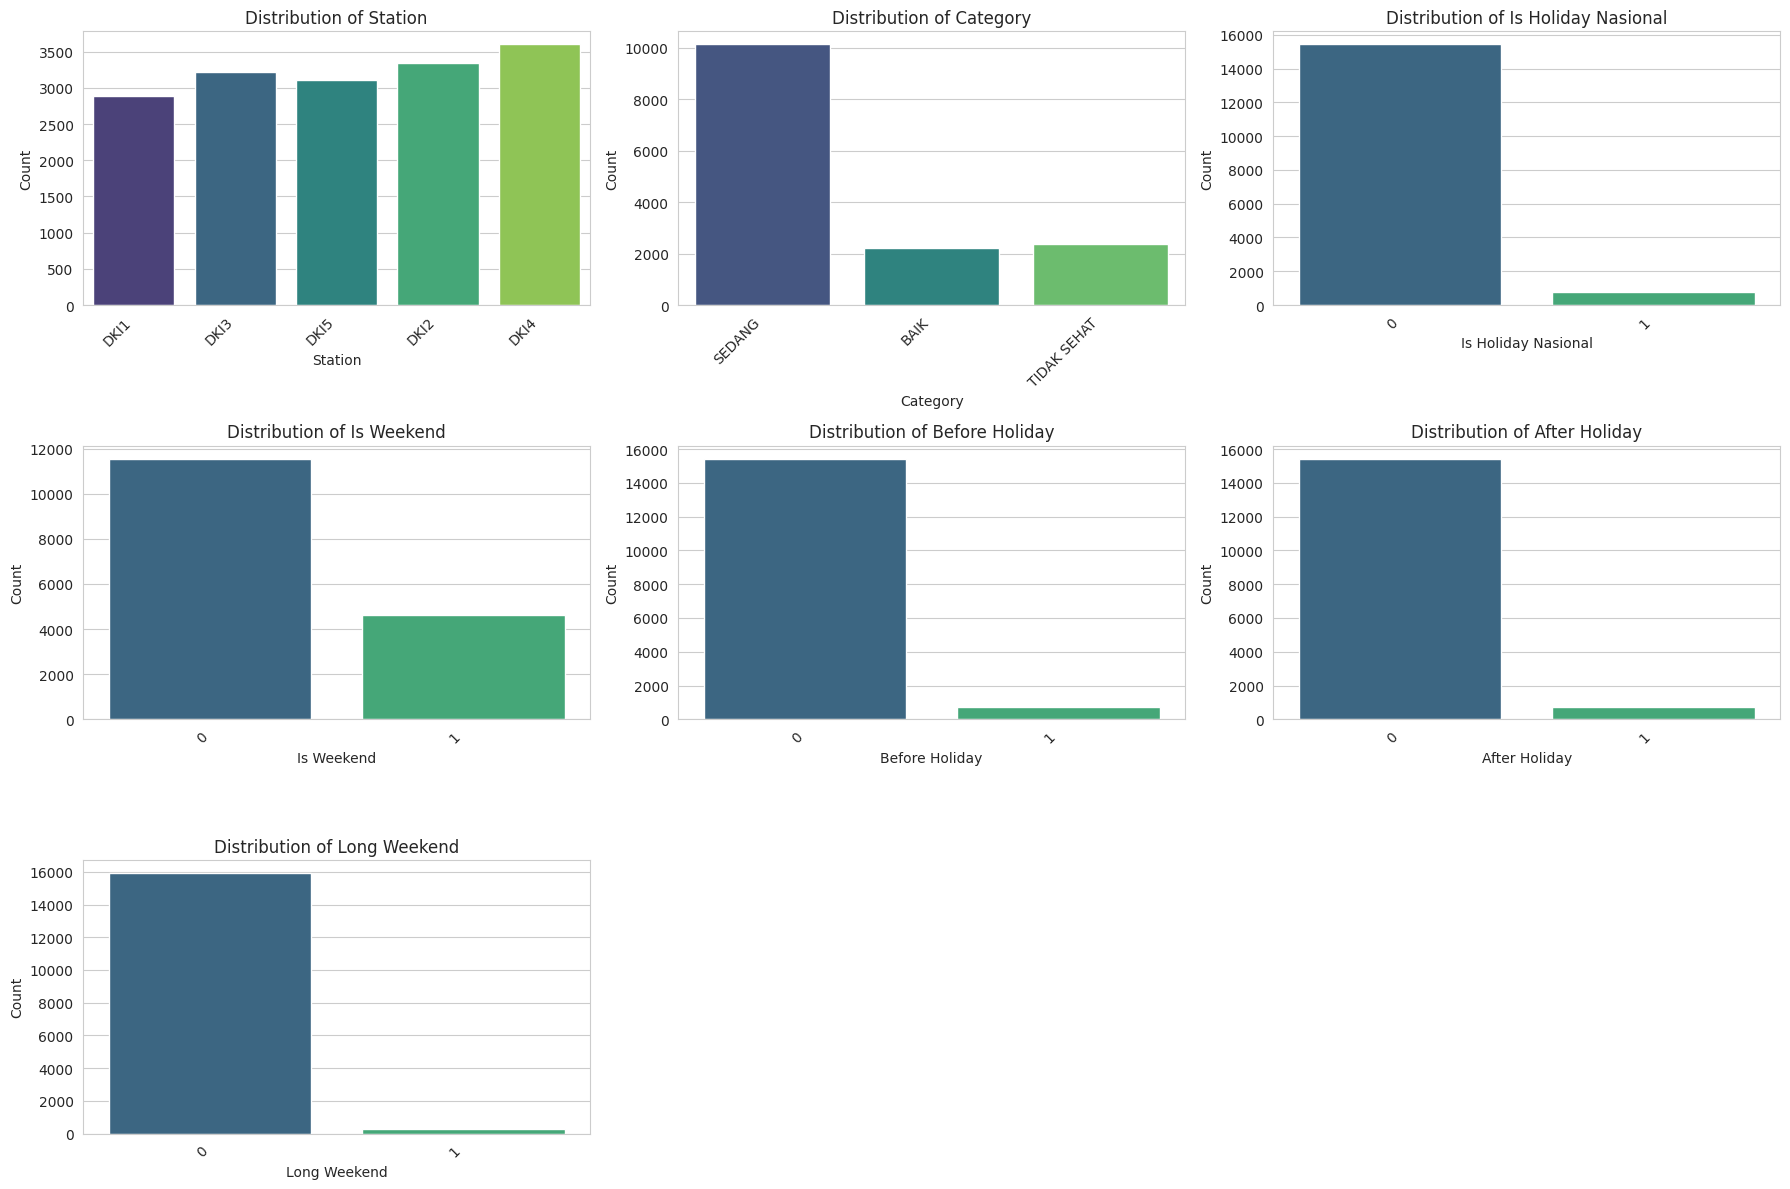

In [ ]:
categorical_cols = [
    'station', 'category', 'is_holiday_nasional', 'is_weekend',
    'before_holiday', 'after_holiday', 'long_weekend'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(data=master, x=col, palette='viridis')
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


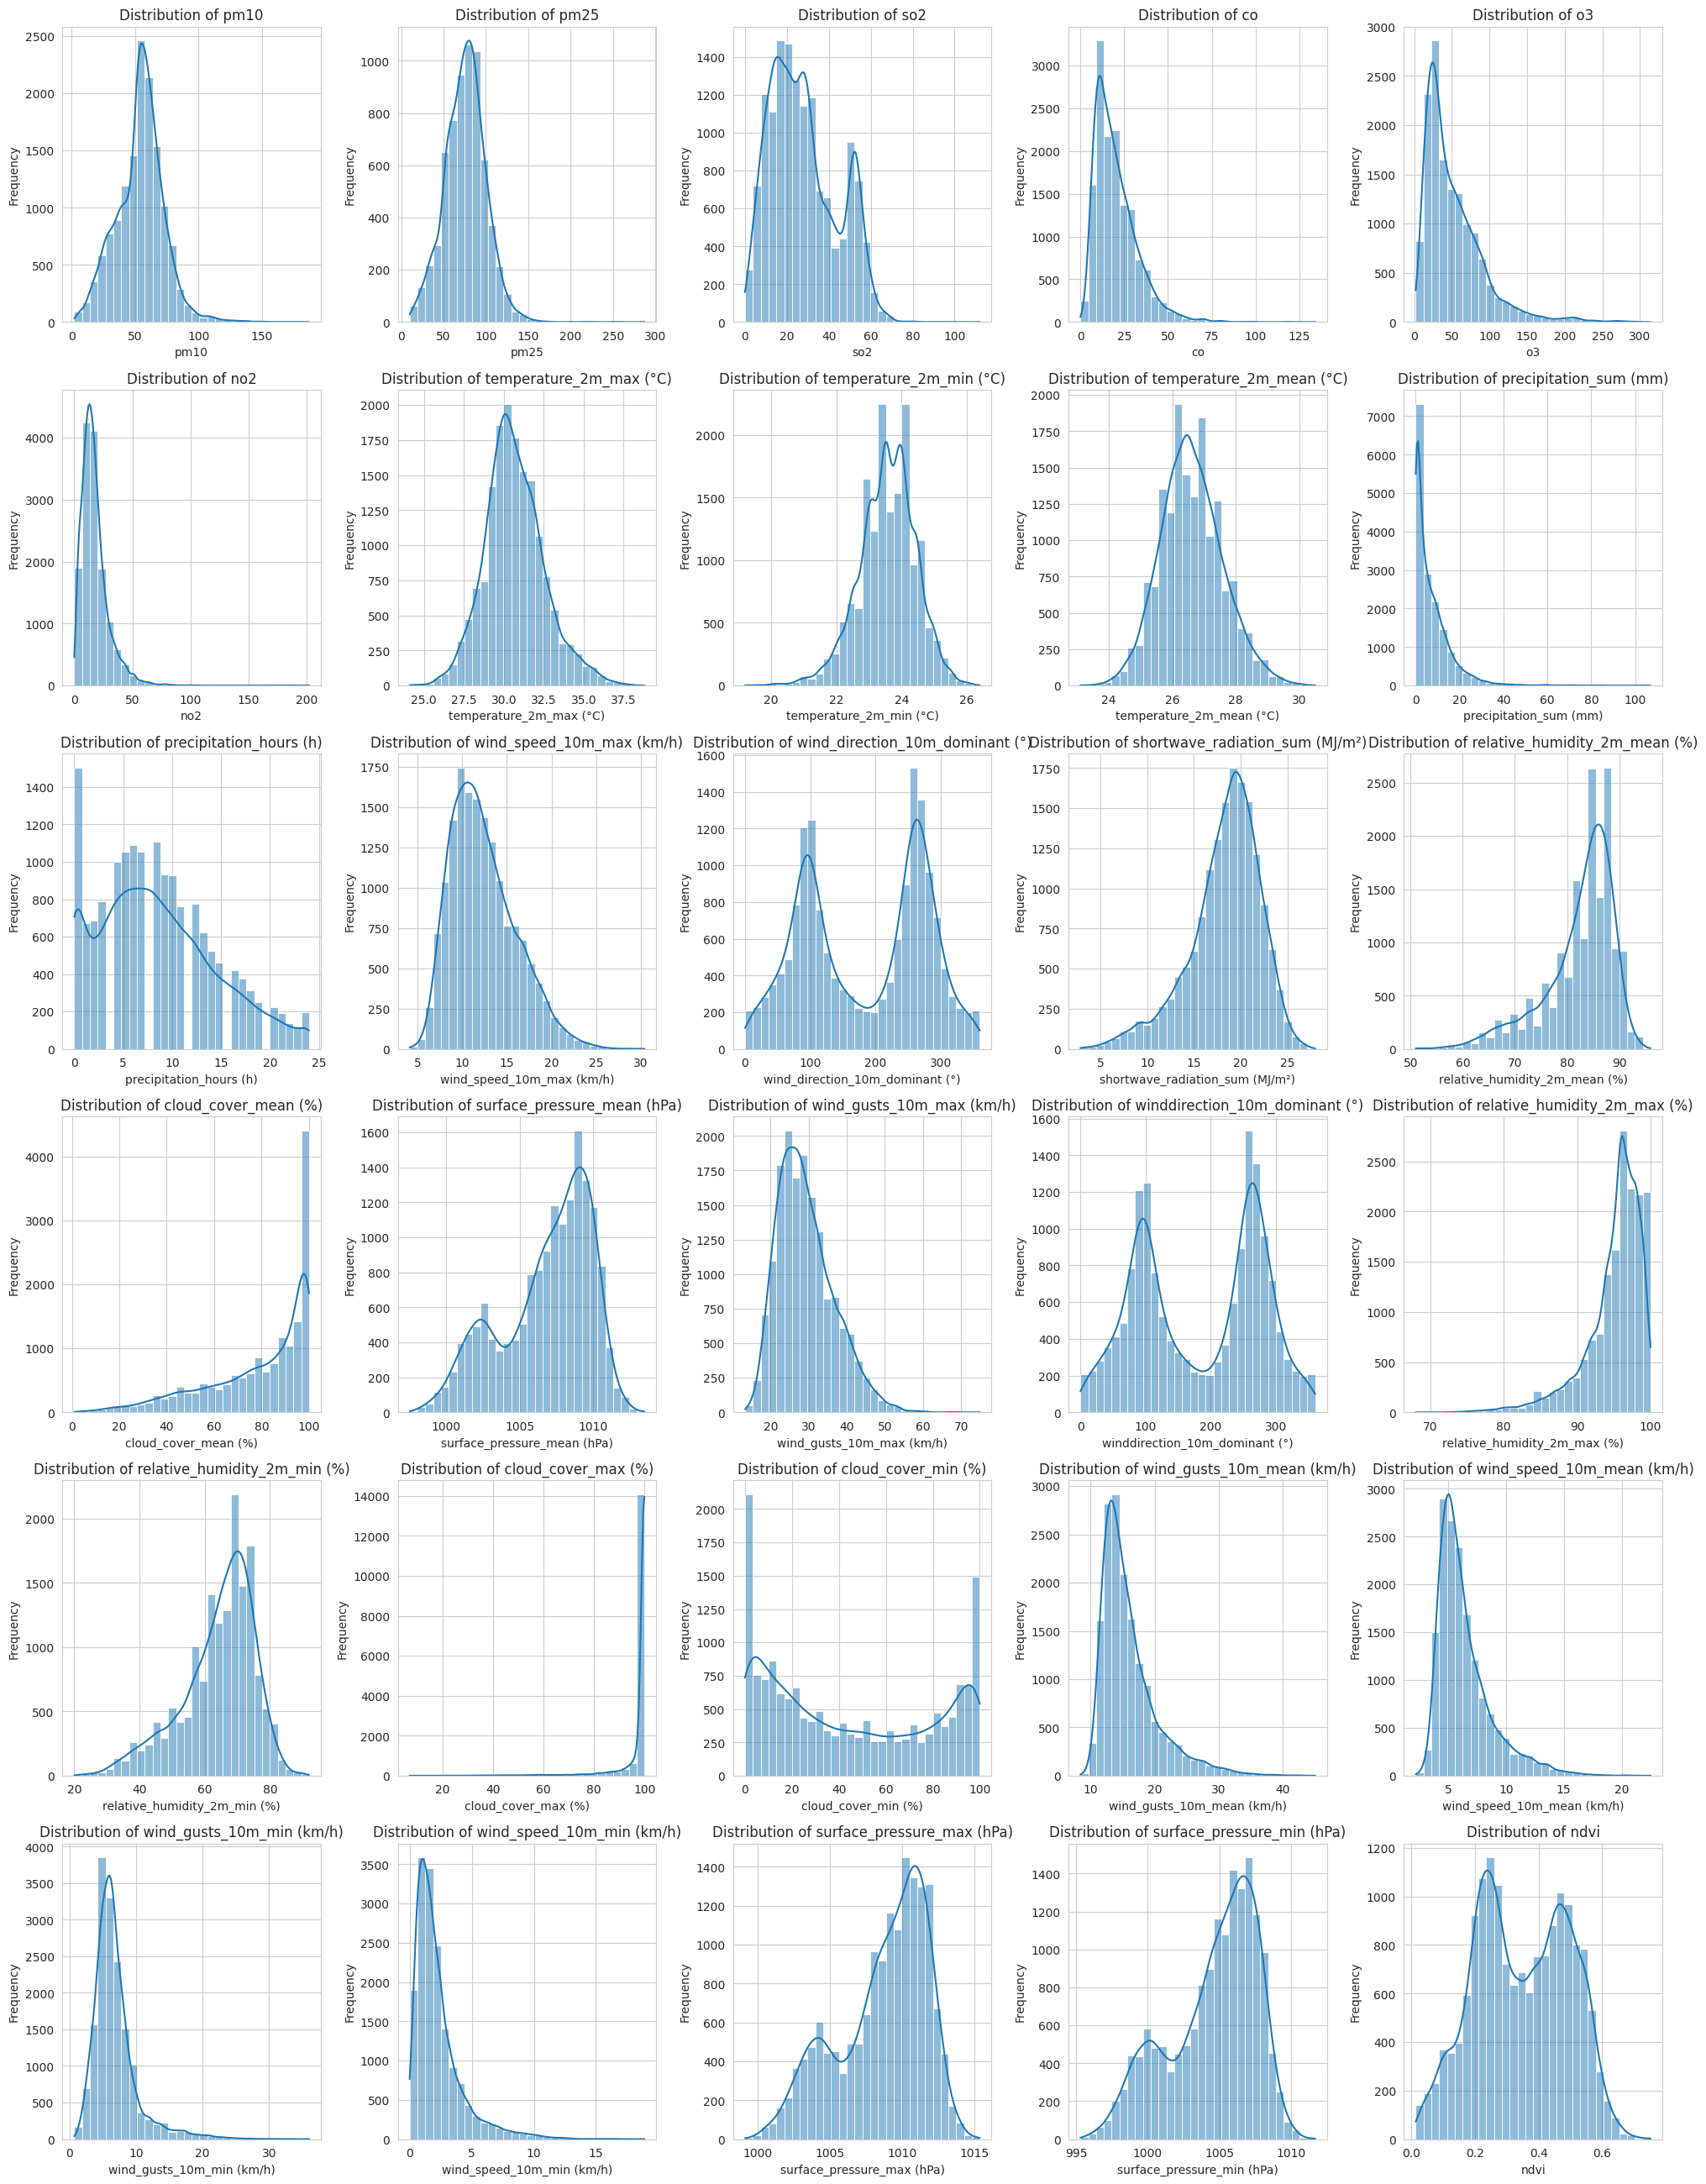

In [ ]:
numerical_cols_for_dist = [
    'pm10', 'pm25', 'so2', 'co', 'o3', 'no2',
    'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'temperature_2m_mean (°C)',
    'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)',
    'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)',
    'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)', 'surface_pressure_mean (hPa)',
    'wind_gusts_10m_max (km/h)', 'winddirection_10m_dominant (°)',
    'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'cloud_cover_max (%)',
    'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)',
    'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)',
    'surface_pressure_min (hPa)', 'ndvi'
]

# Filter out columns that might not be purely numerical or are object types due to mixed types
numerical_cols_for_dist = [col for col in numerical_cols_for_dist if col in master.columns and pd.api.types.is_numeric_dtype(master[col])]

plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_cols_for_dist):
    plt.subplot(7, 5, i + 1) # Adjust subplot grid as needed
    sns.histplot(master[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

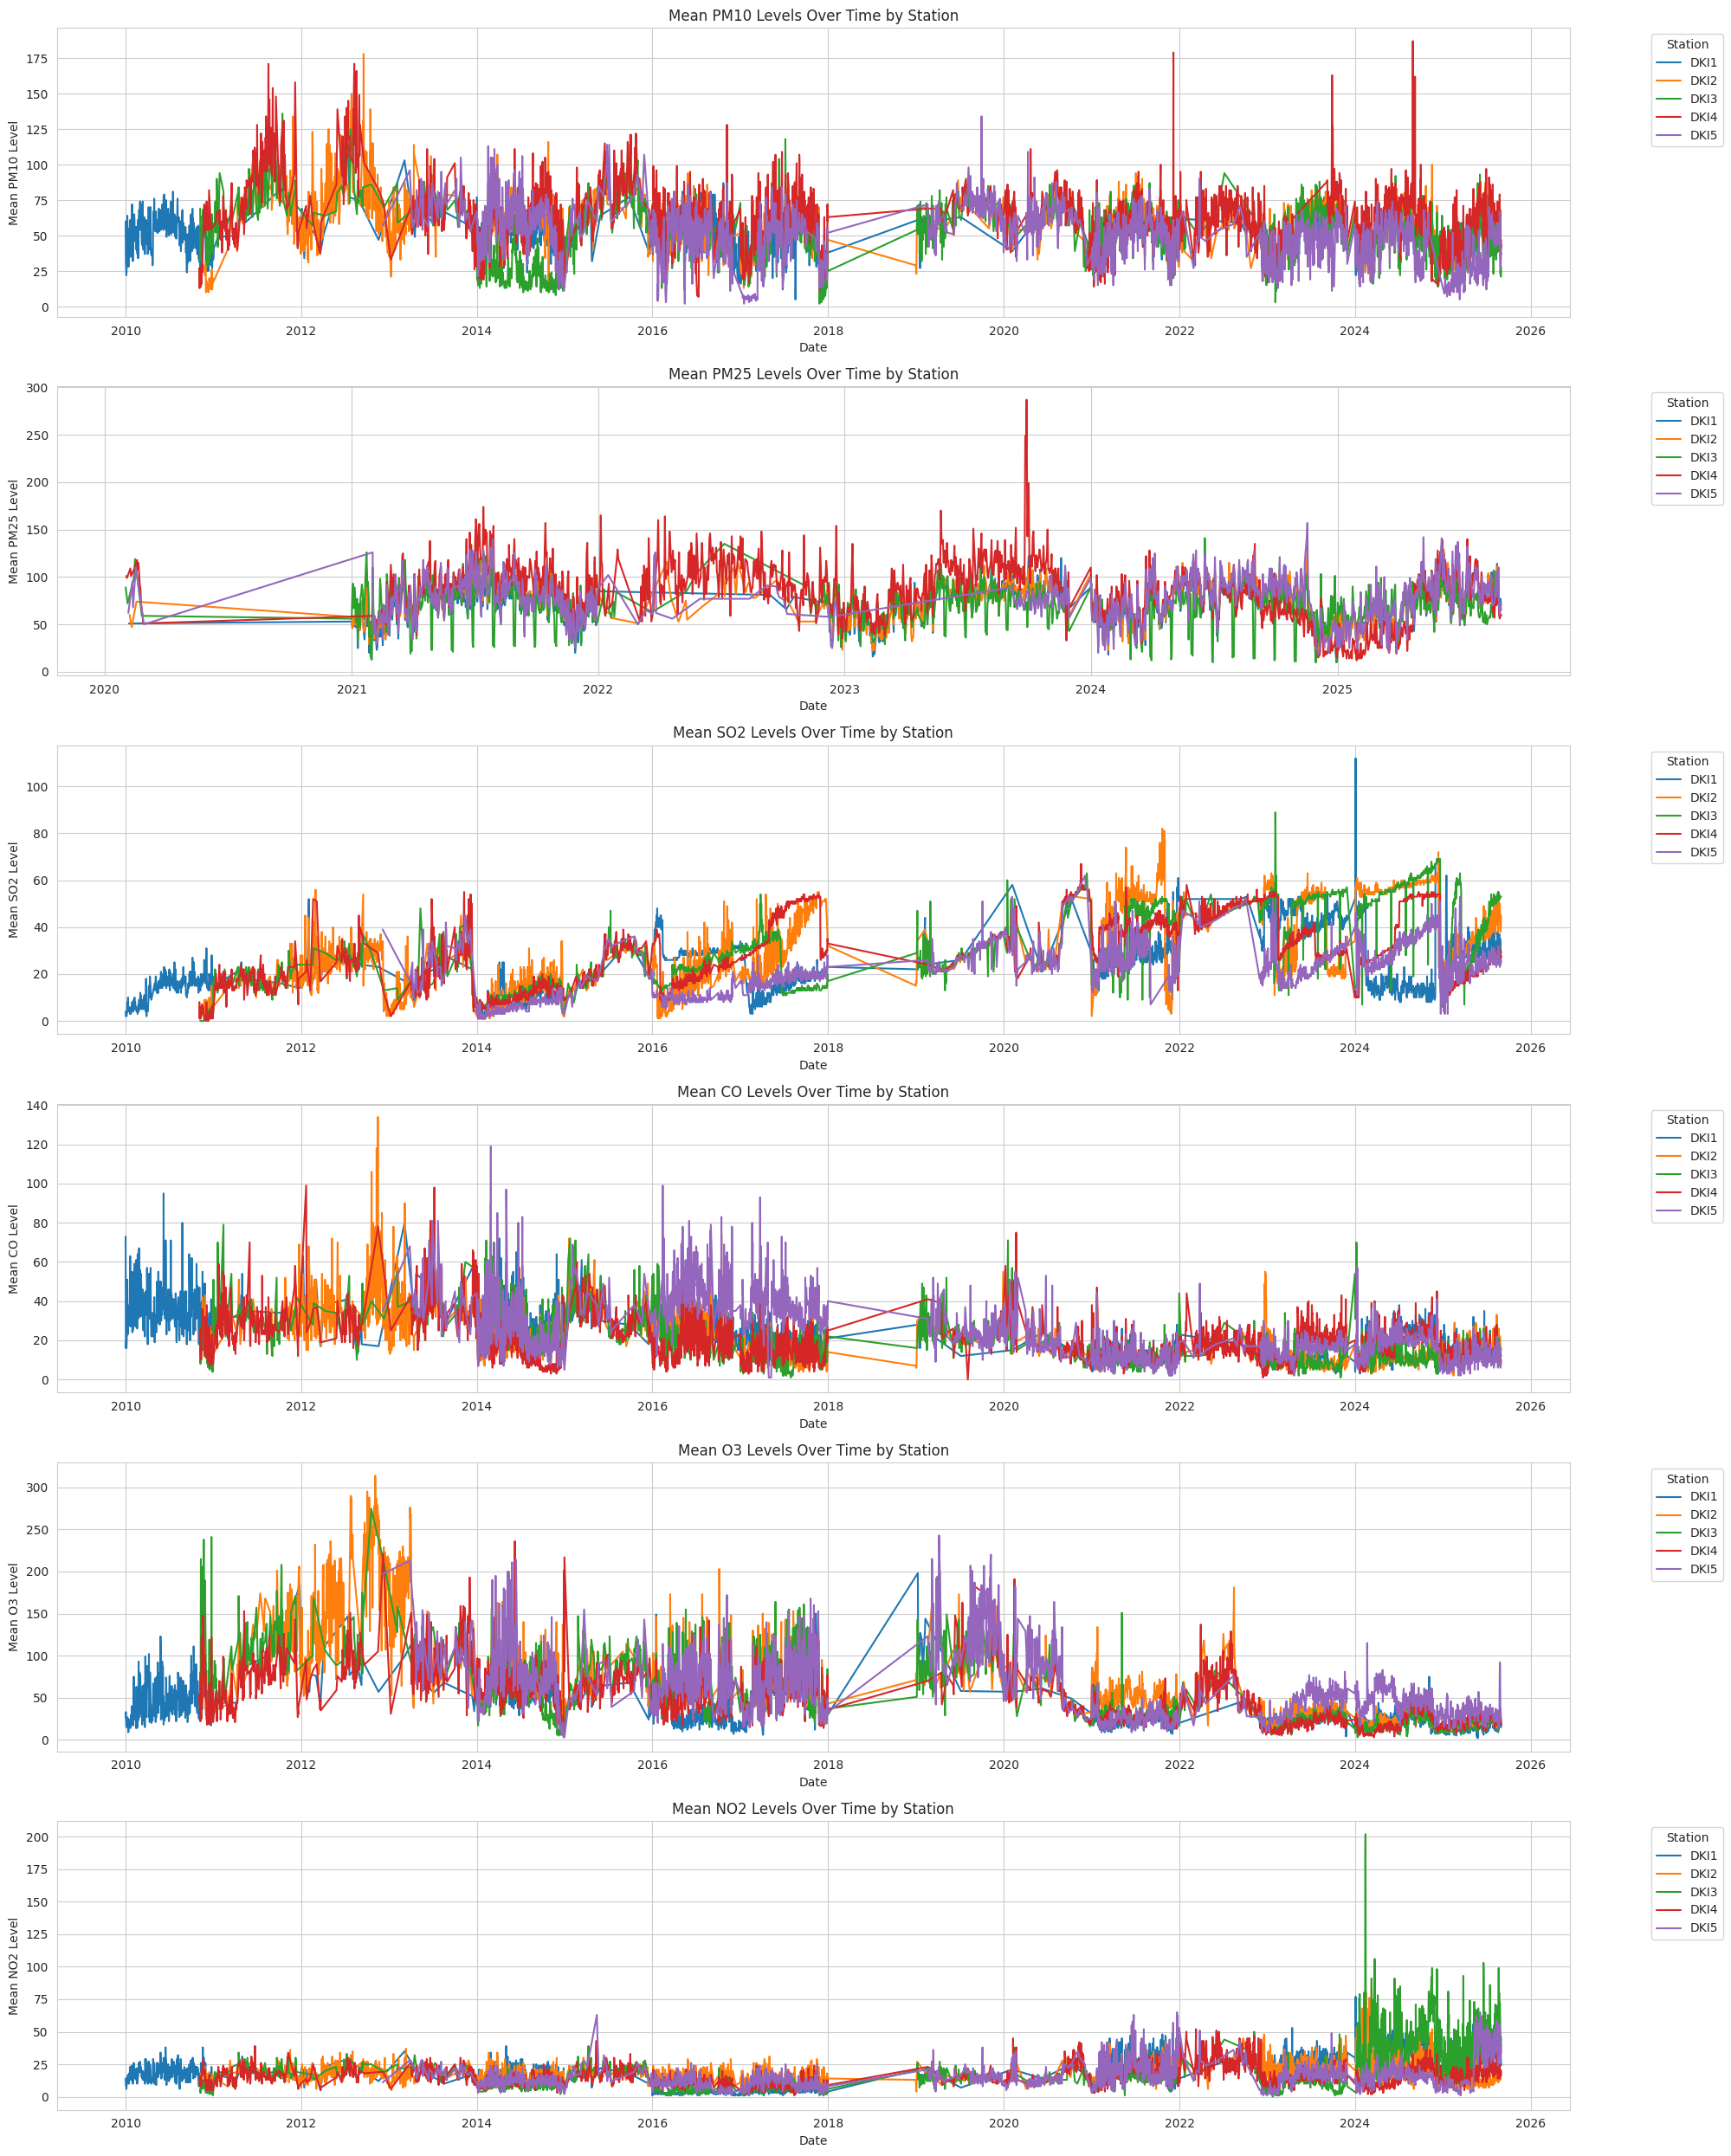

In [ ]:
major_pollutants = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

plt.figure(figsize=(20, 25))

for i, pollutant in enumerate(major_pollutants):
    plt.subplot(len(major_pollutants), 1, i + 1)

    # Convert pollutant columns to numeric, coercing errors to NaN
    master[pollutant] = pd.to_numeric(master[pollutant], errors='coerce')

    # Group by tanggal and station and calculate mean pollutant levels
    pollutant_trend = master.groupby(['tanggal', 'station'])[pollutant].mean().unstack()

    # Plot the trend for each station
    sns.lineplot(data=pollutant_trend, dashes=False)

    plt.title(f'Mean {pollutant.upper()} Levels Over Time by Station')
    plt.xlabel('Date')
    plt.ylabel(f'Mean {pollutant.upper()} Level')
    plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Data Preparation

In [ ]:
from sklearn.preprocessing import LabelEncoder

master = master[master["category"].notna()]

# --- drop leakage ---
X_all = master.drop(columns=["category", "critical", "max"])
y_all = master["category"]

# --- encode target ONCE ---
le = LabelEncoder()
y_all_enc = le.fit_transform(y_all)

# --- add quarter info ---
X_all = X_all.copy()
X_all["year"] = X_all["tanggal"].dt.year
X_all["quarter"] = X_all["tanggal"].dt.to_period("Q")

# --- build rolling quarter folds ---
folds = []
quarters = sorted(X_all["quarter"].unique())

MIN_TRAIN_QUARTERS = 8  # at least 2 years history

for i in range(MIN_TRAIN_QUARTERS, len(quarters)):
    val_q = quarters[i]

    train_mask = X_all["quarter"] < val_q
    val_mask   = X_all["quarter"] == val_q

    folds.append({
        "train_idx": X_all.index[train_mask],
        "val_idx": X_all.index[val_mask],
        "val_quarter": val_q
    })

print(f"Total folds: {len(folds)}")
print("First validation quarter:", folds[0]["val_quarter"])

Total folds: 51
First validation quarter: 2012Q1


In [ ]:
master["dayofyear"] = master["tanggal"].dt.dayofyear
master["dayofyear_sin"] = np.sin(2 * np.pi * master["dayofyear"] / 365)
master["dayofyear_cos"] = np.cos(2 * np.pi * master["dayofyear"] / 365)

# =========================
# FEATURES
# =========================
features = [
    "station",  # categorical
    "dayofyear_sin",
    "dayofyear_cos",
    "temperature_2m_mean (°C)",
    "precipitation_sum (mm)",
    "wind_speed_10m_mean (km/h)",
    "relative_humidity_2m_mean (%)",
    "surface_pressure_mean (hPa)",
    "cloud_cover_mean (%)",
    "ndvi"
]

X = master[features]
y = master["category"]

# =========================
# TIME-BASED SPLIT
# =========================
split_date = master["tanggal"].quantile(0.8)

X_train = X[master["tanggal"] <= split_date]
y_train = y[master["tanggal"] <= split_date]

X_valid = X[master["tanggal"] > split_date]
y_valid = y[master["tanggal"] > split_date]

cat_features = ["station"]


In [ ]:
master

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),month,dayofweek,month_sin,month_cos,station_encoded,station_risk,ndvi,year,is_holiday_nasional,is_weekend,before_holiday,after_holiday,long_weekend,dayofyear,dayofyear_sin,dayofyear_cos
0,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73,CO,SEDANG,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,1,4,0.500000,0.866025,0,0.0,0.2023,2010,1,0,1,0,0,1,0.017213,0.999852
1,2010-01-02,DKI1,32.0,NaN,2.0,16.0,33.0,9.0,33,O3,BAIK,30.8,24.0,6.5,4.0,14.7,238,19.80,26.9,82,99,1008.1,31.3,238,93,69,100,91,16.5,7.7,9.0,4.4,1009.9,1006.0,1,5,0.500000,0.866025,0,0.0,0.2023,2010,0,1,0,0,0,2,0.034422,0.999407
2,2010-01-03,DKI1,27.0,NaN,2.0,19.0,20.0,9.0,27,PM10,BAIK,30.4,24.3,7.6,11.0,12.6,244,17.32,26.7,83,97,1008.5,26.6,244,91,70,100,81,18.4,9.4,11.9,6.5,1010.5,1006.5,1,6,0.500000,0.866025,0,0.0,0.2023,2010,0,1,0,0,0,3,0.051620,0.998667
3,2010-01-04,DKI1,22.0,NaN,2.0,16.0,15.0,6.0,22,PM10,BAIK,30.3,25.4,0.9,5.0,19.3,239,20.43,27.4,81,69,1007.5,34.2,239,91,70,100,17,23.8,13.5,14.4,9.6,1009.1,1005.1,1,0,0.500000,0.866025,0,0.0,0.2023,2010,0,0,0,0,0,4,0.068802,0.997630
4,2010-01-05,DKI1,25.0,NaN,2.0,17.0,15.0,8.0,25,PM10,BAIK,29.9,24.8,14.3,7.0,15.9,247,15.86,26.4,83,100,1007.7,32.0,247,89,72,100,99,21.6,11.1,10.4,7.8,1009.1,1006.0,1,1,0.500000,0.866025,0,0.0,0.2023,2010,0,0,0,0,0,5,0.085965,0.996298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2887,2025-08-31,DKI1,42.0,70.0,29.0,12.0,15.0,24.0,70.0,PM25,SEDANG,31.1,24.0,6.4,5.0,10.9,88,19.23,27.0,80,73,1009.9,30.6,88,95,60,100,6,15.3,4.7,4.3,1.0,1011.6,1007.8,8,6,-0.866025,-0.500000,0,0.0,0.4940,2025,0,1,0,0,0,243,-0.863142,-0.504961
9462,2025-08-31,DKI3,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG,31.3,23.0,14.2,8.0,9.1,132,19.35,26.2,84,67,1002.6,27.0,132,98,59,100,5,14.0,4.5,3.2,0.4,1004.1,1000.4,8,6,-0.866025,-0.500000,2,0.3,0.4797,2025,0,1,0,0,0,243,-0.863142,-0.504961
13065,2025-08-31,DKI4,47.0,59.0,27.0,10.0,18.0,17.0,59.0,PM25,SEDANG,31.6,23.0,12.6,6.0,10.0,122,19.03,26.5,82,64,1006.6,25.6,122,99,59,100,7,14.2,5.1,4.0,0.9,1008.1,1004.4,8,6,-0.866025,-0.500000,3,0.2,0.5774,2025,0,1,0,0,0,243,-0.863142,-0.504961
6239,2025-08-31,DKI2,NaN,72.0,45.0,16.0,21.0,16.0,72.0,PM25,SEDANG,31.0,23.8,19.2,8.0,10.9,99,19.73,26.9,80,74,1009.7,32.4,99,95,60,100,8,19.0,5.9,7.2,0.8,1011.5,1007.4,8,6,-0.866025,-0.500000,1,4.8,0.2276,2025,0,1,0,0,0,243,-0.863142,-0.504961


In [ ]:
master['category'].unique()

array(['SEDANG', 'BAIK', 'TIDAK SEHAT'], dtype=object)

# Stage 1

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

class_counts = y_train.value_counts()
class_weights = {cls: class_counts.max() / count for cls, count in class_counts.items()}

# =========================
# MODEL
# =========================
model = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=600,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    class_weights=class_weights,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=["station"],
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

# =========================
# VALIDATION
# =========================
preds = model.predict(X_valid)
print(classification_report(y_valid, preds))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.7 MB/s eta 0:00:00
0:	learn: 1.0835394	test: 1.0843975	best: 1.0843975 (0)	total: 80.1ms	remaining: 48s
100:	learn: 0.7978370	test: 0.8710395	best: 0.8708924 (96)	total: 2.29s	remaining: 11.3s
200:	learn: 0.7466564	test: 0.8640537	best: 0.8639223 (199)	total: 4.4s	remaining: 8.74s
300:	learn: 0.6921882	test: 0.8592321	best: 0.8592321 (300)	total: 6.78s	remaining: 6.73s
400:	learn: 0.6507479	test: 0.8618973	best: 0.8591223 (342)	total: 10.5s	remaining: 5.22s
500:	learn: 0.6212215	test: 0.8654681	best: 0.8591223 (342)	total: 12.9s	remaining: 2.55s
599:	learn: 0.5937889	test: 0.8692028	best: 0.8591223 (342)	total: 15.2s	remaining: 0us

bestTest = 0.8591223448
bestIteration = 342

Shrink model to first 343 iterations.
              precision    recall  f1-score   support

        BAIK       0.42      0.63      0.50       375
      SEDANG       0.82      0.50      0.62      2251
 TIDAK SEHAT       0.18      0.55      0.27       316


In [ ]:
master['category'].value_counts()

,count
category,
SEDANG,10138
TIDAK SEHAT,2364
BAIK,2222


In [ ]:
master

,tanggal,station,pm10,pm25,so2,co,o3,no2,max,critical,category,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),month,dayofweek,month_sin,month_cos,station_encoded,station_risk,ndvi,year,is_holiday_nasional,is_weekend,before_holiday,after_holiday,long_weekend,dayofyear,dayofyear_sin,dayofyear_cos
0,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73,CO,SEDANG,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,1,4,0.500000,0.866025,0,0.0,0.2023,2010,1,0,1,0,0,1,0.017213,0.999852
1,2010-01-02,DKI1,32.0,NaN,2.0,16.0,33.0,9.0,33,O3,BAIK,30.8,24.0,6.5,4.0,14.7,238,19.80,26.9,82,99,1008.1,31.3,238,93,69,100,91,16.5,7.7,9.0,4.4,1009.9,1006.0,1,5,0.500000,0.866025,0,0.0,0.2023,2010,0,1,0,0,0,2,0.034422,0.999407
2,2010-01-03,DKI1,27.0,NaN,2.0,19.0,20.0,9.0,27,PM10,BAIK,30.4,24.3,7.6,11.0,12.6,244,17.32,26.7,83,97,1008.5,26.6,244,91,70,100,81,18.4,9.4,11.9,6.5,1010.5,1006.5,1,6,0.500000,0.866025,0,0.0,0.2023,2010,0,1,0,0,0,3,0.051620,0.998667
3,2010-01-04,DKI1,22.0,NaN,2.0,16.0,15.0,6.0,22,PM10,BAIK,30.3,25.4,0.9,5.0,19.3,239,20.43,27.4,81,69,1007.5,34.2,239,91,70,100,17,23.8,13.5,14.4,9.6,1009.1,1005.1,1,0,0.500000,0.866025,0,0.0,0.2023,2010,0,0,0,0,0,4,0.068802,0.997630
4,2010-01-05,DKI1,25.0,NaN,2.0,17.0,15.0,8.0,25,PM10,BAIK,29.9,24.8,14.3,7.0,15.9,247,15.86,26.4,83,100,1007.7,32.0,247,89,72,100,99,21.6,11.1,10.4,7.8,1009.1,1006.0,1,1,0.500000,0.866025,0,0.0,0.2023,2010,0,0,0,0,0,5,0.085965,0.996298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2887,2025-08-31,DKI1,42.0,70.0,29.0,12.0,15.0,24.0,70.0,PM25,SEDANG,31.1,24.0,6.4,5.0,10.9,88,19.23,27.0,80,73,1009.9,30.6,88,95,60,100,6,15.3,4.7,4.3,1.0,1011.6,1007.8,8,6,-0.866025,-0.500000,0,0.0,0.4940,2025,0,1,0,0,0,243,-0.863142,-0.504961
9462,2025-08-31,DKI3,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG,31.3,23.0,14.2,8.0,9.1,132,19.35,26.2,84,67,1002.6,27.0,132,98,59,100,5,14.0,4.5,3.2,0.4,1004.1,1000.4,8,6,-0.866025,-0.500000,2,0.3,0.4797,2025,0,1,0,0,0,243,-0.863142,-0.504961
13065,2025-08-31,DKI4,47.0,59.0,27.0,10.0,18.0,17.0,59.0,PM25,SEDANG,31.6,23.0,12.6,6.0,10.0,122,19.03,26.5,82,64,1006.6,25.6,122,99,59,100,7,14.2,5.1,4.0,0.9,1008.1,1004.4,8,6,-0.866025,-0.500000,3,0.2,0.5774,2025,0,1,0,0,0,243,-0.863142,-0.504961
6239,2025-08-31,DKI2,NaN,72.0,45.0,16.0,21.0,16.0,72.0,PM25,SEDANG,31.0,23.8,19.2,8.0,10.9,99,19.73,26.9,80,74,1009.7,32.4,99,95,60,100,8,19.0,5.9,7.2,0.8,1011.5,1007.4,8,6,-0.866025,-0.500000,1,4.8,0.2276,2025,0,1,0,0,0,243,-0.863142,-0.504961


In [ ]:
df = master.copy()

# Ensure datetime
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Use CLEAN label if available
TARGET = 'category'   # change to 'category_clean' if you have it

# Drop rows with missing target
df = df.dropna(subset=[TARGET])

FEATURES = [
    # Pollution
    'pm10', 'pm25', 'so2', 'co', 'o3', 'no2',

    # Weather (aggregated)
    'temperature_2m_mean (°C)',
    'relative_humidity_2m_mean (%)',
    'wind_speed_10m_mean (km/h)',
    'precipitation_sum (mm)',
    'cloud_cover_mean (%)',
    'surface_pressure_mean (hPa)',

    # Temporal
    'month', 'dayofweek',
    'month_sin', 'month_cos',
    'dayofyear_sin', 'dayofyear_cos',
    'year',

    # Spatial / station
    'station_encoded',
    'station_risk',
    'ndvi',

    # Calendar effects
    'is_holiday_nasional',
    'is_weekend',
    'before_holiday',
    'after_holiday',
    'long_weekend',
]


In [ ]:
SPLIT_DATE = '2024-01-01'

train_df = df[df['tanggal'] < SPLIT_DATE]
val_df   = df[df['tanggal'] >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]


In [ ]:
class_counts = y_train.value_counts()
total = class_counts.sum()

class_weights = {
    cls: total / (len(class_counts) * cnt)
    for cls, cnt in class_counts.items()
}

print("Class weights:", class_weights)


Class weights: {'SEDANG': np.float64(0.49910394265232977), 'TIDAK SEHAT': np.float64(1.9075342465753424), 'BAIK': np.float64(2.11787072243346)}


In [ ]:
model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    class_weights=class_weights,
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)


0:	learn: 0.9609425	test: 0.9258983	best: 0.9258983 (0)	total: 151ms	remaining: 2m 30s
100:	learn: 0.9962209	test: 0.9776718	best: 0.9778654 (39)	total: 6.43s	remaining: 57.2s
200:	learn: 0.9977445	test: 0.9784030	best: 0.9791336 (190)	total: 10.5s	remaining: 41.6s
300:	learn: 0.9987842	test: 0.9784030	best: 0.9791336 (190)	total: 15.7s	remaining: 36.4s
400:	learn: 0.9989123	test: 0.9784030	best: 0.9791336 (190)	total: 19.4s	remaining: 29s
500:	learn: 0.9994879	test: 0.9785966	best: 0.9791336 (190)	total: 23.2s	remaining: 23.1s
600:	learn: 0.9996586	test: 0.9785966	best: 0.9791336 (190)	total: 28.4s	remaining: 18.8s
700:	learn: 0.9997440	test: 0.9785966	best: 0.9791336 (190)	total: 32.1s	remaining: 13.7s
800:	learn: 0.9999147	test: 0.9785966	best: 0.9791336 (190)	total: 35.9s	remaining: 8.92s
900:	learn: 0.9999573	test: 0.9785966	best: 0.9791336 (190)	total: 41s	remaining: 4.5s
999:	learn: 0.9999573	test: 0.9785966	best: 0.9791336 (190)	total: 44.7s	remaining: 0us

bestTest = 0.9791336

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
val_pred = model.predict(X_val)

print(classification_report(y_val, val_pred))
print(confusion_matrix(y_val, val_pred))


              precision    recall  f1-score   support

        BAIK       0.99      0.95      0.97       381
      SEDANG       0.99      1.00      0.99      2326
 TIDAK SEHAT       0.99      0.98      0.99       320

    accuracy                           0.99      3027
   macro avg       0.99      0.98      0.98      3027
weighted avg       0.99      0.99      0.99      3027

[[ 362   19    0]
 [   5 2318    3]
 [   0    5  315]]


In [ ]:
sample = pd.read_csv(SAMPLE_SUB_PATH)


sample[['tanggal', 'station']] = sample['id'].str.split('_', expand=True)
sample['tanggal'] = pd.to_datetime(sample['tanggal'])



In [ ]:
sample

,id,category,tanggal,station
0,2025-09-01_DKI1,NaN,2025-09-01,DKI1
1,2025-09-01_DKI2,NaN,2025-09-01,DKI2
2,2025-09-01_DKI3,NaN,2025-09-01,DKI3
3,2025-09-01_DKI4,NaN,2025-09-01,DKI4
4,2025-09-01_DKI5,NaN,2025-09-01,DKI5
...,...,...,...,...
450,2025-11-30_DKI1,NaN,2025-11-30,DKI1
451,2025-11-30_DKI2,NaN,2025-11-30,DKI2
452,2025-11-30_DKI3,NaN,2025-11-30,DKI3
453,2025-11-30_DKI4,NaN,2025-11-30,DKI4


In [ ]:
sample['year'] = sample['tanggal'].dt.year
sample['month'] = sample['tanggal'].dt.month
sample['dayofweek'] = sample['tanggal'].dt.dayofweek
sample['dayofyear'] = sample['tanggal'].dt.dayofyear

sample['month_sin'] = np.sin(2 * np.pi * sample['month'] / 12)
sample['month_cos'] = np.cos(2 * np.pi * sample['month'] / 12)

sample['dayofyear_sin'] = np.sin(2 * np.pi * sample['dayofyear'] / 365)
sample['dayofyear_cos'] = np.cos(2 * np.pi * sample['dayofyear'] / 365)


In [ ]:
station_map = (
    df[['station', 'station_encoded']]
    .drop_duplicates()
    .set_index('station')['station_encoded']
    .to_dict()
)

sample['station_encoded'] = sample['station'].map(station_map)


In [ ]:
station_static = (
    df.groupby('station')
    .agg({
        'station_risk': 'mean',
        'ndvi': 'mean'
    })
)

sample = sample.join(station_static, on='station')


In [ ]:
CLIM_FEATURES = [
    'pm10', 'pm25', 'so2', 'co', 'o3', 'no2',
    'temperature_2m_mean (°C)',
    'relative_humidity_2m_mean (%)',
    'wind_speed_10m_mean (km/h)',
    'precipitation_sum (mm)',
    'cloud_cover_mean (%)',
    'surface_pressure_mean (hPa)',
]

climatology = (
    df.groupby(['station', 'month'])[CLIM_FEATURES]
    .mean()
    .reset_index()
)

sample = sample.merge(
    climatology,
    on=['station', 'month'],
    how='left'
)


In [ ]:
# Ensure all features exist
for col in FEATURES:
    if col not in sample.columns:
        sample[col] = 0

X_test = sample[FEATURES]

test_pred = model.predict(X_test)
test_pred = test_pred.astype(str)

sample['category'] = test_pred


In [ ]:
sample['category'].value_counts()

,count
category,
SEDANG,455


In [ ]:
sample

,id,category,tanggal,station,year,month,dayofweek,dayofyear,month_sin,month_cos,dayofyear_sin,dayofyear_cos,station_encoded,station_risk,ndvi,pm10,pm25,so2,co,o3,no2,temperature_2m_mean (°C),relative_humidity_2m_mean (%),wind_speed_10m_mean (km/h),precipitation_sum (mm),cloud_cover_mean (%),surface_pressure_mean (hPa),is_holiday_nasional,is_weekend,before_holiday,after_holiday,long_weekend
0,2025-09-01_DKI1,SEDANG,2025-09-01,DKI1,2025,9,0,244,-1.0,-1.836970e-16,-0.871706,-0.490029,0,0.0,0.218314,54.785000,80.877778,22.976415,22.037736,42.090047,20.117925,27.278302,76.000000,6.112736,3.737264,68.372642,1009.690566,0,0,0,0,0
1,2025-09-01_DKI2,SEDANG,2025-09-01,DKI2,2025,9,0,244,-1.0,-1.836970e-16,-0.871706,-0.490029,1,4.8,0.218476,67.258242,83.466667,36.595376,14.076503,70.295082,19.398907,27.577596,73.519126,7.265027,2.435519,62.404372,1009.636066,0,0,0,0,0
2,2025-09-01_DKI3,SEDANG,2025-09-01,DKI3,2025,9,0,244,-1.0,-1.836970e-16,-0.871706,-0.490029,2,0.3,0.445121,56.454545,73.505747,36.197861,15.245989,65.572193,18.224599,27.420856,71.465241,6.534225,2.937968,62.106952,1002.507487,0,0,0,0,0
3,2025-09-01_DKI4,SEDANG,2025-09-01,DKI4,2025,9,0,244,-1.0,-1.836970e-16,-0.871706,-0.490029,3,0.2,0.459847,75.155000,97.495495,38.847926,16.646789,50.000000,18.672811,27.564679,72.133028,6.724771,3.816055,64.321101,1006.473394,0,0,0,0,0
4,2025-09-01_DKI5,SEDANG,2025-09-01,DKI5,2025,9,0,244,-1.0,-1.836970e-16,-0.871706,-0.490029,4,1.1,0.344289,53.937143,80.872093,25.519231,18.620879,64.101796,14.187845,27.690710,72.513661,6.463934,2.721311,62.377049,1009.040437,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2025-11-30_DKI1,SEDANG,2025-11-30,DKI1,2025,11,6,334,-0.5,8.660254e-01,-0.508671,0.860961,0,0.0,0.218314,48.658537,68.898876,23.756098,23.723301,41.946078,19.102439,26.879612,83.101942,5.815534,8.936408,89.461165,1008.404369,0,0,0,0,0
451,2025-11-30_DKI2,SEDANG,2025-11-30,DKI2,2025,11,6,334,-0.5,8.660254e-01,-0.508671,0.860961,1,4.8,0.218476,56.632184,73.453488,29.062731,23.302158,84.460432,20.974820,26.867143,82.557143,6.207143,8.210714,87.925000,1008.216071,0,0,0,0,0
452,2025-11-30_DKI3,SEDANG,2025-11-30,DKI3,2025,11,6,334,-0.5,8.660254e-01,-0.508671,0.860961,2,0.3,0.445121,47.162896,65.164948,34.140969,16.391111,55.669683,18.800000,26.353304,84.303965,5.832599,9.317621,88.506608,1001.030396,0,0,0,0,0
453,2025-11-30_DKI4,SEDANG,2025-11-30,DKI4,2025,11,6,334,-0.5,8.660254e-01,-0.508671,0.860961,3,0.2,0.459847,57.019920,72.819048,36.384615,18.744186,52.976834,18.393939,26.547955,84.070632,5.892193,9.837918,89.464684,1005.103346,0,0,0,0,0
